In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Plant 1 generation data (note: DD-MM-YYYY format)
gen_p1 = pd.read_csv('../data/Plant_1_Generation_Data.csv')
gen_p1['DATE_TIME'] = pd.to_datetime(gen_p1['DATE_TIME'], format='%d-%m-%Y %H:%M')

# Load Plant 2 generation data (note: YYYY-MM-DD format - different!)
gen_p2 = pd.read_csv('../data/Plant_2_Generation_Data.csv')
gen_p2['DATE_TIME'] = pd.to_datetime(gen_p2['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# Quick check both loaded correctly
print("Plant 1 rows:", len(gen_p1), "| Date range:", gen_p1['DATE_TIME'].min(), "to", gen_p1['DATE_TIME'].max())
print("Plant 2 rows:", len(gen_p2), "| Date range:", gen_p2['DATE_TIME'].min(), "to", gen_p2['DATE_TIME'].max())

Plant 1 rows: 68778 | Date range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Plant 2 rows: 67698 | Date range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Plant 1 generation data (note: DD-MM-YYYY format)
gen_p1 = pd.read_csv('../data/Plant_1_Generation_Data.csv')
gen_p1['DATE_TIME'] = pd.to_datetime(gen_p1['DATE_TIME'], format='%d-%m-%Y %H:%M')

# Load Plant 2 generation data (note: YYYY-MM-DD format - different!)
gen_p2 = pd.read_csv('../data/Plant_2_Generation_Data.csv')
gen_p2['DATE_TIME'] = pd.to_datetime(gen_p2['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# Quick check both loaded correctly
print("Plant 1 rows:", len(gen_p1), "| Date range:", gen_p1['DATE_TIME'].min(), "to", gen_p1['DATE_TIME'].max())
print("Plant 2 rows:", len(gen_p2), "| Date range:", gen_p2['DATE_TIME'].min(), "to", gen_p2['DATE_TIME'].max())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Plant 1 generation data (note: DD-MM-YYYY format)
gen_p1 = pd.read_csv('../data/Plant_1_Generation_Data.csv')
gen_p1['DATE_TIME'] = pd.to_datetime(gen_p1['DATE_TIME'], format='%d-%m-%Y %H:%M')

# Load Plant 2 generation data (note: YYYY-MM-DD format - different!)
gen_p2 = pd.read_csv('../data/Plant_2_Generation_Data.csv')
gen_p2['DATE_TIME'] = pd.to_datetime(gen_p2['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

# Quick check both loaded correctly
print("Plant 1 rows:", len(gen_p1), "| Date range:", gen_p1['DATE_TIME'].min(), "to", gen_p1['DATE_TIME'].max())
print("Plant 2 rows:", len(gen_p2), "| Date range:", gen_p2['DATE_TIME'].min(), "to", gen_p2['DATE_TIME'].max())

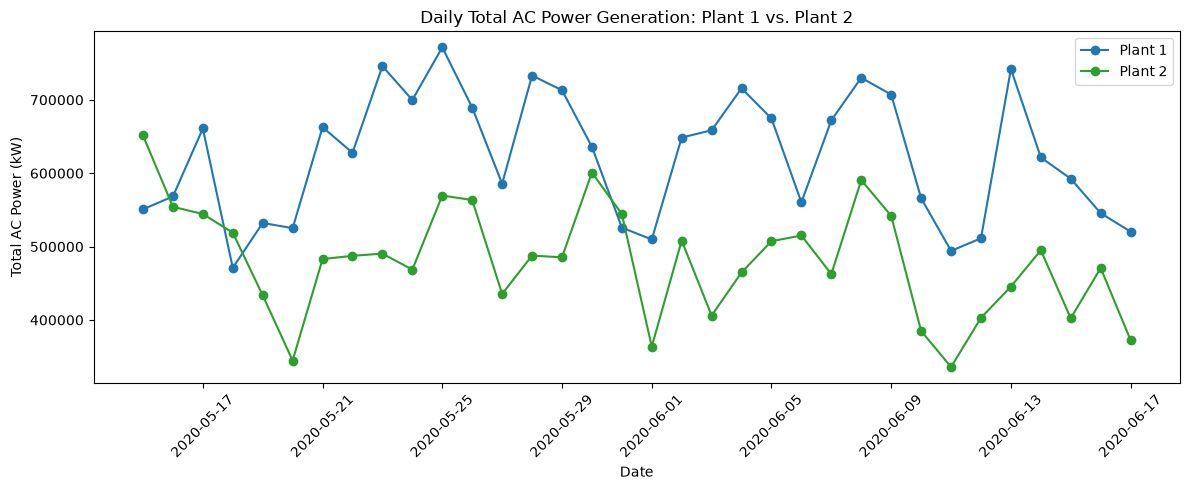

In [2]:
# Add DATE columns (date only, no time) for both plants
gen_p1['DATE'] = gen_p1['DATE_TIME'].dt.date
gen_p2['DATE'] = gen_p2['DATE_TIME'].dt.date

# Sum AC_POWER across all inverters, grouped by day, for each plant
daily_p1 = gen_p1.groupby('DATE')['AC_POWER'].sum()
daily_p2 = gen_p2.groupby('DATE')['AC_POWER'].sum()

# Plot both together
plt.figure(figsize=(12, 5))
plt.plot(daily_p1.index, daily_p1.values, marker='o', label='Plant 1', color='tab:blue')
plt.plot(daily_p2.index, daily_p2.values, marker='o', label='Plant 2', color='tab:green')

plt.title('Daily Total AC Power Generation: Plant 1 vs. Plant 2')
plt.xlabel('Date')
plt.ylabel('Total AC Power (kW)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Finding: Plant 1 consistently outperforms Plant 2

Across the full 34-day period, Plant 1's daily total AC power output 
is consistently higher than Plant 2's ,both plants rise and fall on 
the same days (e.g. dips around 2020-05-19/20, 2020-06-01/02, and 
2020-06-10/11), indicating similar weather exposure. The gap between
them stays roughly proportional throughout, rather than widening or 
narrowing over time.

**Takeaway:** Since both plants track the same weather pattern but 
Plant 1 consistently outputs more, the difference is most likely due 
to installed capacity (more panels/inverters) rather than a 
weather-driven or developing equipment issue.

In [3]:
# Load Plant 2's weather sensor data
weather_p2 = pd.read_csv('../data/Plant_2_Weather_Sensor_Data.csv')

# Convert DATE_TIME to a real datetime (check format matches Plant 1's weather file)
weather_p2['DATE_TIME'] = pd.to_datetime(weather_p2['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

weather_p2.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4136001,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,4136001,iq8k7ZNt4Mwm3w0,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,4136001,iq8k7ZNt4Mwm3w0,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,4136001,iq8k7ZNt4Mwm3w0,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,4136001,iq8k7ZNt4Mwm3w0,26.596148,25.088210,0.0


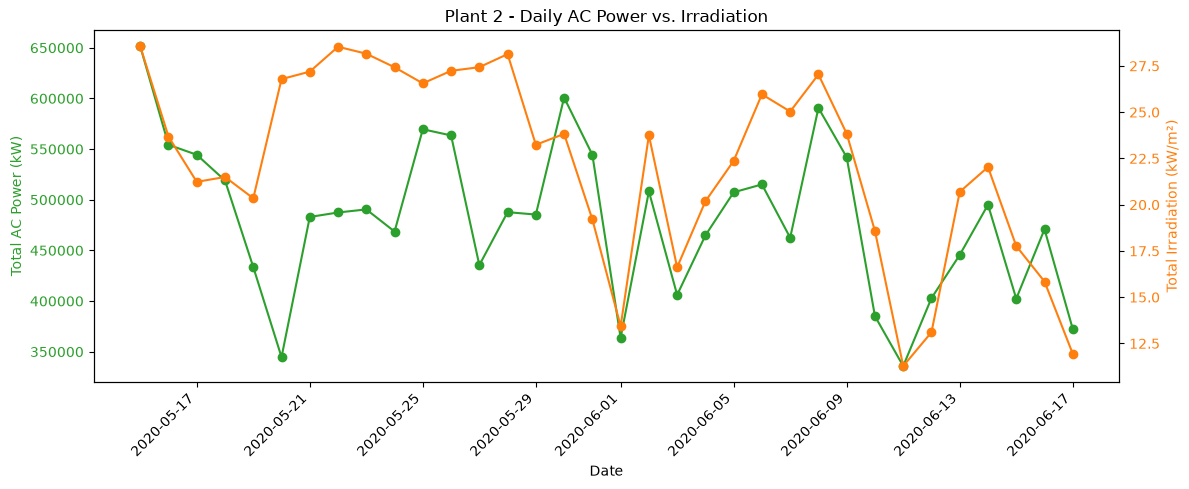

In [4]:
# Aggregate Plant 2 generation to one row per timestamp (summing all inverters)
plant2_total_power = gen_p2.groupby('DATE_TIME')['AC_POWER'].sum().reset_index()

# Merge with weather data
merged_p2 = pd.merge(plant2_total_power, weather_p2[['DATE_TIME', 'IRRADIATION']], on='DATE_TIME', how='inner')

# Aggregate to daily totals for both metrics
merged_p2['DATE'] = merged_p2['DATE_TIME'].dt.date
daily_comparison_p2 = merged_p2.groupby('DATE')[['AC_POWER', 'IRRADIATION']].sum().reset_index()

# Plot with two y-axes, same style as Plant 1's chart
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(daily_comparison_p2['DATE'], daily_comparison_p2['AC_POWER'], color='tab:green', marker='o', label='AC Power')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total AC Power (kW)', color='tab:green')
ax1.tick_params(axis='y', labelcolor='tab:green')

ax2 = ax1.twinx()
ax2.plot(daily_comparison_p2['DATE'], daily_comparison_p2['IRRADIATION'], color='tab:orange', marker='o', label='Irradiation')
ax2.set_ylabel('Total Irradiation (kW/m²)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Plant 2 - Daily AC Power vs. Irradiation')
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

## Finding: Plant 2 shows a period of irradiation/power mismatch (unlike Plant 1)

Unlike Plant 1, where AC power closely tracked irradiation throughout, 
Plant 2 shows a clear divergence between 2020-05-19 and 2020-05-27: 
irradiation remains high and fairly stable (~26-28 kW/m²) while AC 
power drops and fluctuates well below what irradiation alone would 
predict. From approximately 2020-06-01 onward, the two metrics track 
closely again, similar to Plant 1's overall pattern.

**Takeaway:** This mismatch window suggests a possible equipment issue 
at Plant 2 during this period (e.g. inverter downtime, a tripped 
string, soiling that later cleared) rather than a purely weather-driven 
cause. Combined with Plant 2's overall lower output versus Plant 1, 
this strengthens the case that Plant 2 may have had a real, temporary 
performance problem — worth a deeper inverter-level look, same as we 
did for Plant 1.

In [5]:
inverter_avg_p2 = gen_p2.groupby('SOURCE_KEY')['DC_POWER'].mean().sort_values()
inverter_avg_p2

SOURCE_KEY
Quc1TzYxW2pYoWX    173.254729
Et9kgGMDl729KT4    188.230376
LYwnQax7tkwH5Cb    196.286078
rrq4fwE8jgrTyWY    209.158443
q49J1IKaHRwDQnt    226.161981
81aHJ1q11NBPMrL    230.796317
xoJJ8DcxJEcupym    240.926951
9kRcWv60rDACzjR    244.653027
WcxssY2VbP4hApt    245.274699
LlT2YUhhzqhg5Sw    245.493296
PeE6FRyGXUgsRhN    248.689407
oZZkBaNadn6DNKz    255.921141
vOuJvMaM2sgwLmb    262.096623
V94E5Ben1TlhnDV    262.158843
NgDl19wMapZy17u    273.522084
mqwcsP2rE7J0TFp    275.701451
oZ35aAeoifZaQzV    277.042840
4UPUqMRk7TRMgml    277.760524
Qf4GUc1pJu5T6c6    278.746893
xMbIugepa2P7lBB    280.712467
Mx2yZCDsyf6DPfv    285.013230
IQ2d7wF4YD8zU1Q    285.525112
Name: DC_POWER, dtype: float64

In [7]:
gen_p2['DATE'] = gen_p2['DATE_TIME'].dt.date

import datetime
mismatch_window = gen_p2[(gen_p2['DATE'] >= datetime.date(2020, 5, 19)) & (gen_p2['DATE'] <= datetime.date(2020, 5, 27))]

inverter_avg_window = mismatch_window.groupby('SOURCE_KEY')['DC_POWER'].mean().sort_values()
inverter_avg_window


SOURCE_KEY
LYwnQax7tkwH5Cb    198.542844
Quc1TzYxW2pYoWX    200.270282
81aHJ1q11NBPMrL    213.752628
rrq4fwE8jgrTyWY    236.676674
Et9kgGMDl729KT4    239.851867
q49J1IKaHRwDQnt    248.779200
xoJJ8DcxJEcupym    256.340660
PeE6FRyGXUgsRhN    265.962451
9kRcWv60rDACzjR    267.857811
LlT2YUhhzqhg5Sw    288.039183
WcxssY2VbP4hApt    291.654621
oZZkBaNadn6DNKz    292.553477
vOuJvMaM2sgwLmb    294.792131
mqwcsP2rE7J0TFp    310.576094
NgDl19wMapZy17u    310.675948
xMbIugepa2P7lBB    314.289951
IQ2d7wF4YD8zU1Q    318.041970
Qf4GUc1pJu5T6c6    335.222059
4UPUqMRk7TRMgml    337.726935
V94E5Ben1TlhnDV    342.586836
oZ35aAeoifZaQzV    360.824533
Mx2yZCDsyf6DPfv    360.901062
Name: DC_POWER, dtype: float64

In [8]:
# Check average module temperature during the mismatch window vs. the rest of the period
weather_p2['DATE'] = weather_p2['DATE_TIME'].dt.date

window_weather = weather_p2[(weather_p2['DATE'] >= datetime.date(2020, 5, 19)) & (weather_p2['DATE'] <= datetime.date(2020, 5, 27))]
rest_weather = weather_p2[~((weather_p2['DATE'] >= datetime.date(2020, 5, 19)) & (weather_p2['DATE'] <= datetime.date(2020, 5, 27)))]

print("Avg module temp during mismatch window:", window_weather['MODULE_TEMPERATURE'].mean())
print("Avg module temp rest of period:", rest_weather['MODULE_TEMPERATURE'].mean())

Avg module temp during mismatch window: 35.38319033551129
Avg module temp rest of period: 31.832046820177855


## Finding: May 19-27 mismatch explained by elevated module temperature, not equipment fault

Initial inverter-level comparison showed the irradiation/power mismatch 
during 2020-05-19 to 2020-05-27 was NOT caused by a single faulty 
inverter, nearly all 22 inverters showed similar or higher average 
output during this window compared to the full period, ruling out an 
isolated equipment issue.

Checking module temperature confirmed a likely cause: average module 
temperature during the mismatch window was 35.4°C, versus 31.8°C for 
the rest of the period,  a 3.6°C increase. Since panel efficiency drops 
as module temperature rises, this plant-wide temperature increase is a 
more plausible explanation than a hardware fault.

**Takeaway:** Unlike Plant 1 (whose variability was fully explained by 
irradiation alone) and the isolated June 13 inverter anomaly, this 
mismatch reflects a normal physical phenomenon, thermal derating, 
rather than a fault requiring maintenance action. Good example of why 
irradiation alone isn't sufficient for performance validation; module 
temperature should be checked too.

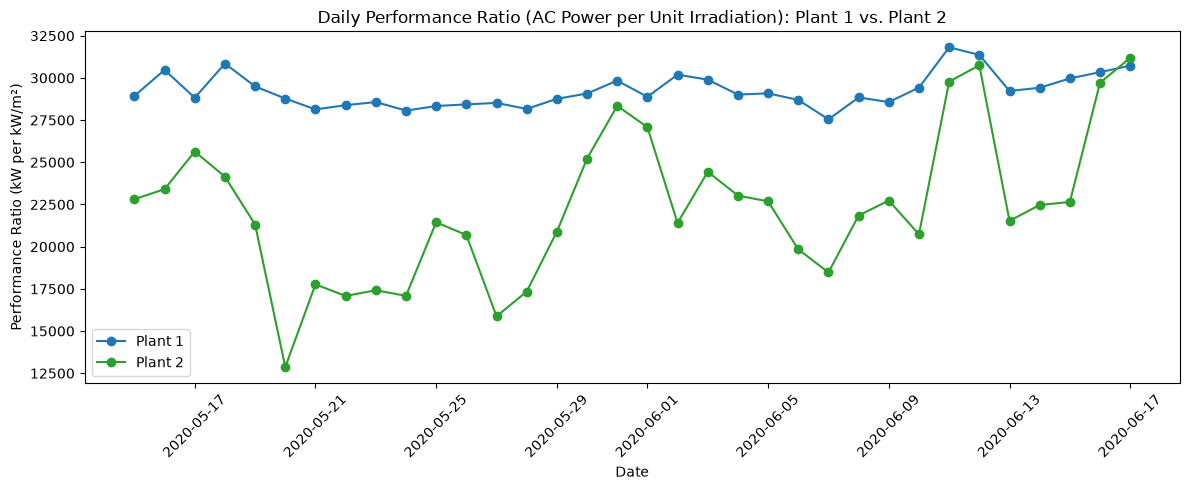

In [9]:
# Performance ratio = AC_POWER / IRRADIATION
# This tells us how much power each plant produces per unit of available sunlight,
# letting us compare efficiency independent of system size

# Re-merge Plant 1 data (irradiation + power) if not already available in this notebook
weather_p1 = pd.read_csv('../data/Plant_1_Weather_Sensor_Data.csv')
weather_p1['DATE_TIME'] = pd.to_datetime(weather_p1['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

plant1_total_power = gen_p1.groupby('DATE_TIME')['AC_POWER'].sum().reset_index()
merged_p1 = pd.merge(plant1_total_power, weather_p1[['DATE_TIME', 'IRRADIATION']], on='DATE_TIME', how='inner')
merged_p1['DATE'] = merged_p1['DATE_TIME'].dt.date

# Aggregate to daily totals for Plant 1
daily_p1_full = merged_p1.groupby('DATE')[['AC_POWER', 'IRRADIATION']].sum().reset_index()

# We already have daily_comparison_p2 with the same structure from earlier

# Calculate performance ratio for each plant, avoiding division by zero on days with no irradiation
daily_p1_full['PERFORMANCE_RATIO'] = daily_p1_full['AC_POWER'] / daily_p1_full['IRRADIATION']
daily_comparison_p2['PERFORMANCE_RATIO'] = daily_comparison_p2['AC_POWER'] / daily_comparison_p2['IRRADIATION']

# Plot both plants' performance ratio over time
plt.figure(figsize=(12, 5))
plt.plot(daily_p1_full['DATE'], daily_p1_full['PERFORMANCE_RATIO'], marker='o', label='Plant 1', color='tab:blue')
plt.plot(daily_comparison_p2['DATE'], daily_comparison_p2['PERFORMANCE_RATIO'], marker='o', label='Plant 2', color='tab:green')

plt.title('Daily Performance Ratio (AC Power per Unit Irradiation): Plant 1 vs. Plant 2')
plt.xlabel('Date')
plt.ylabel('Performance Ratio (kW per kW/m²)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Finding: Plant 1 is genuinely more efficient, not just larger (performance ratio)

Normalizing daily power output by daily irradiation (performance ratio 
= AC Power / Irradiation) shows Plant 1 consistently achieves a higher 
ratio (~28,000-32,000) than Plant 2 (~17,000-25,000, with occasional 
drops below 15,000) across nearly the entire 34-day period.

**Takeaway:** This updates the earlier "Plant 1 outperforms Plant 2" 
finding, the gap is not simply due to system size or capacity 
differences. Since both plants receive similar irradiation and Plant 1 
still converts it into meaningfully more power, Plant 1 is genuinely 
more efficient. This points toward real differences in equipment 
quality, panel condition, or system design between the two plants, 
and would be a strong case for a deeper site inspection at Plant 2 in 
a real-world setting.